In [1]:
!pip install onnxruntime-gpu
!pip install insightface

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)

   ---------------------------------------- 0/3 [opencv-python-headless]
   ---------------------------------------- 0/3 [opencv-python-headless]
   ---------------------------------------- 0/3 [opencv-python-headless]
   ------------- -------------------------- 1/3 [albucore]
   -------------------------- ------------- 2/3 [albumentations]
   -------------------------- ------------- 2/3 [albumentations]
   -------------------------- ------------- 2/3 [albumentations]
   --------------------------

In [2]:
import insightface
from insightface.app import FaceAnalysis
import cv2
from ai.utils.path_utils import is_path_existed
import matplotlib.pyplot as plt
import onnxruntime as ort


In [4]:
MODE = {
    'GPU': 'CUDAExecutionProvider'
}
provider = ort.get_available_providers()
if MODE.get('GPU') not in provider:
    print("You don't have GPU")
else:
    print("You have GPU")

You have GPU


In [7]:
from insightface.app import FaceAnalysis
import cv2
import numpy as np

app = FaceAnalysis(
    name='buffalo_l',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider'],
    allowed_modules=['detection', 'recognition']
)
app.prepare(ctx_id=0, det_size=(640, 640))

img_path = is_path_existed('data/img/Screenshot (29).png')
img = cv2.imread(img_path)
faces = app.get(img)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\Huy Le/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExec

In [16]:
boxes = [face['bbox'] for face in faces]
embe

[array([1570.6229 ,  418.46982, 1639.6521 ,  502.35294], dtype=float32), array([491.68903, 455.5686 , 568.0387 , 558.83923], dtype=float32), array([2279.7136  ,   41.051296, 2345.265   ,  122.68317 ], dtype=float32), array([1941.4836 ,  324.66315, 2007.4708 ,  406.596  ], dtype=float32), array([1026.7036  ,   99.723694, 1098.6781  ,  180.7132  ], dtype=float32), array([2214.0977 ,  695.9872 , 2295.3787 ,  800.99927], dtype=float32), array([ 66.98253, 494.41217, 145.78168, 591.0828 ], dtype=float32), array([1408.9604,  337.0684, 1487.0325,  434.2633], dtype=float32), array([199.39758, 268.1066 , 269.54443, 353.68988], dtype=float32), array([2020.572 ,  807.8707, 2104.0283,  916.776 ], dtype=float32), array([2387.3013 ,  278.11188, 2454.6277 ,  362.42627], dtype=float32), array([2411.5269 ,  483.85135, 2494.3777 ,  575.7854 ], dtype=float32), array([338.5916 , 218.06076, 410.131  , 308.0075 ], dtype=float32), array([1737.986  ,  457.32468, 1803.5061 ,  526.3492 ], dtype=float32), array([

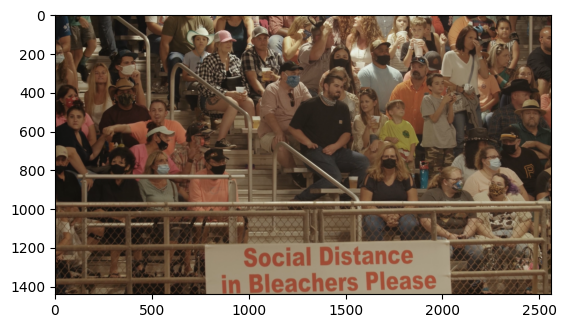

In [12]:
img_path = is_path_existed('data/img/Screenshot (29).png')
img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)

plt.imshow(img)
plt.show()

In [13]:
boxes = process_image(img)
print(boxes)

C:\Users\Huy Le\AppData\Roaming\Python\Python312\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[{'bbox': [1570, 418, 1639, 502], 'embedding': [0.8295373916625977, -0.25532689690589905, -1.5446150302886963, -0.7001907825469971, 0.6880857348442078, 0.24969394505023956, 0.6510035395622253, 1.2498841285705566, -0.28698140382766724, 0.8201146721839905, 2.119967460632324, -1.1293894052505493, -1.1875779628753662, -0.724356472492218, -0.3482258915901184, -0.3142565190792084, -0.3713396489620209, 0.6910758018493652, 0.16046594083309174, -0.4370054304599762, -0.414838582277298, -0.11920687556266785, -0.418003648519516, -0.6061903834342957, -0.3000529706478119, -0.16544188559055328, 0.2623536288738251, 0.03777308389544487, 0.9022934436798096, -0.46347588300704956, 1.4980567693710327, 1.19723641872406, -0.6967561841011047, 0.8908568024635315, -0.24081991612911224, 1.4315401315689087, 1.7653306722640991, -0.6042748689651489, -0.9402716159820557, 0.1169964000582695, 0.32980263233184814, 0.9672202467918396, -1.3753299713134766, -3.396157741546631, -1.0952281951904297, -0.12312991172075272, 1.